# 04b — Random Forest

Random Forest lane for the 30-day readmission comparison. To keep it a fair comparison with the
logistic regression (04) and HGBC (04c) lanes, this uses the same cleaned data, the same 80/20
stratified split (`random_state=42`), the same preprocessing, and the same metrics.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_recall_curve,
    precision_score, recall_score, RocCurveDisplay, roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.config import TARGET, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR

In [2]:
df = pd.read_csv(PROCESSED_DIR / "cleaned.csv")
print(df.shape)

(3000, 15)


## Train/test split

Same split as the other lanes, so the test set is identical.

In [3]:
if "patient_id" in df.columns:
    df = df.drop(columns=["patient_id"])

X = df.drop(columns=[TARGET])
y = df[TARGET]

numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("train:", X_train.shape, " test:", X_test.shape)

train: (2400, 14)  test: (600, 14)


## Preprocessing

Numeric features are median-imputed and scaled; categorical features are mode-imputed and one-hot
encoded. Random Forest does not really need scaling, but we keep the shared pipeline so all three
models see the same inputs.

In [4]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

## Model and a small grid search

Keeping the tuning light: a 2x2 grid over `max_depth` and `min_samples_leaf` (the two knobs that
matter most for overfitting), 5-fold CV scored on AUROC. `n_estimators` is fixed at 300.

In [5]:
rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
])

param_grid = {
    "model__max_depth": [None, 12],
    "model__min_samples_leaf": [1, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(rf, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV AUROC:", round(grid.best_score_, 4))
best_rf = grid.best_estimator_

Best params: {'model__max_depth': 12, 'model__min_samples_leaf': 5}
Best CV AUROC: 0.6884


## Evaluation

Metrics on the held-out test set, against the same most-frequent dummy baseline used in the other
lanes. Results are saved to `tbl_rf_results.csv` so notebook 06 can pick up the Random Forest row.

In [6]:
def evaluate(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "specificity": tn / (tn + fp),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "average_precision": average_precision_score(y_test, y_score),
    }

results = pd.DataFrame([
    evaluate("Dummy baseline", DummyClassifier(strategy="most_frequent")),
    evaluate("Random Forest", best_rf),
]).sort_values("roc_auc", ascending=False)

results.to_csv(TABLES_DIR / "tbl_rf_results.csv", index=False)
results.round(4)

,model,accuracy,recall,specificity,precision,f1,roc_auc,average_precision
1,Random Forest,0.6283,0.3806,0.8017,0.5732,0.4574,0.6812,0.5717
0,Dummy baseline,0.5883,0.0000,1.0000,0.0000,0.0000,0.5000,0.4117


              precision    recall  f1-score   support

           0      0.649     0.802     0.717       353
           1      0.573     0.381     0.457       247

    accuracy                          0.628       600
   macro avg      0.611     0.591     0.587       600
weighted avg      0.618     0.628     0.610       600



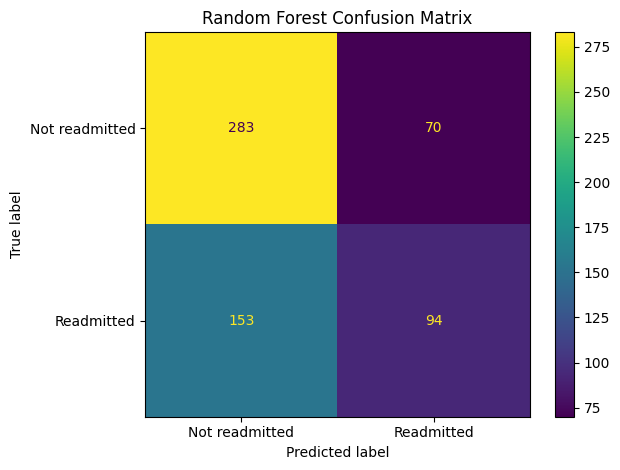

In [7]:
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not readmitted", "Readmitted"]).plot(values_format="d")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_rf_confusion_matrix.png", dpi=300)
plt.show()

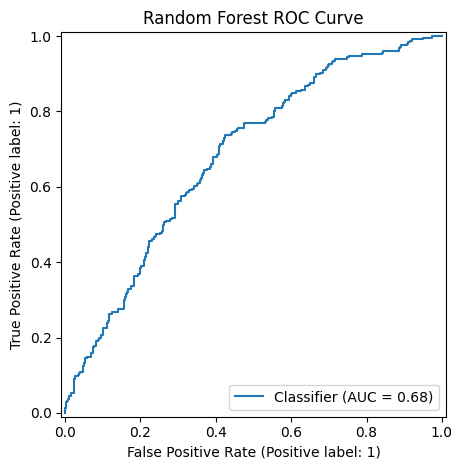

In [8]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Random Forest ROC Curve")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_rf_roc_curve.png", dpi=300)
plt.show()

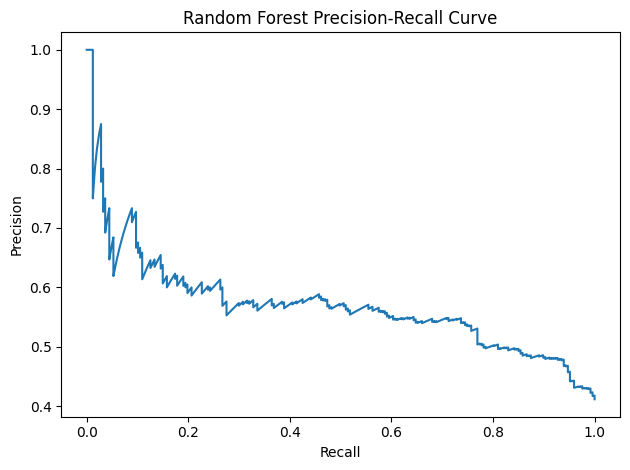

In [9]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision-Recall Curve")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_rf_precision_recall_curve.png", dpi=300)
plt.show()

## Threshold review

The default threshold is 0.50. For screening we also sweep a few lower thresholds on a validation
split carved from the training data (so the test set stays untouched), pick the one with the best
validation F1, and then report test-set metrics at the default and selected thresholds. A lower
threshold catches more at-risk patients (higher recall) at the cost of more false alarms.

In [10]:
THRESHOLDS = [0.30, 0.40, 0.50, 0.60, 0.70]

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42, stratify=y_train
)
threshold_model = clone(best_rf)
threshold_model.fit(X_fit, y_fit)
val_proba = threshold_model.predict_proba(X_val)[:, 1]

rows = []
for t in THRESHOLDS:
    preds = (val_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_val, preds),
        "specificity": tn / (tn + fp),
        "precision": precision_score(y_val, preds, zero_division=0),
        "recall": recall_score(y_val, preds, zero_division=0),
        "f1": f1_score(y_val, preds, zero_division=0),
    })

threshold_review = pd.DataFrame(rows)
threshold_review.to_csv(TABLES_DIR / "tbl_rf_threshold_review_validation.csv", index=False)
threshold_review.round(4)

,threshold,accuracy,specificity,precision,recall,f1
0,0.3,0.5646,0.3534,0.4831,0.8680,0.6207
1,0.4,0.6042,0.5406,0.5131,0.6954,0.5905
2,0.5,0.6292,0.7739,0.5646,0.4213,0.4826
3,0.6,0.6229,0.9435,0.6667,0.1624,0.2612
4,0.7,0.6021,1.0000,1.0000,0.0305,0.0591


In [11]:
selected = threshold_review.loc[threshold_review["f1"].idxmax(), "threshold"]
print("Selected screening threshold:", selected)

rows = []
for t in [0.50, selected]:
    preds = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, preds),
        "specificity": tn / (tn + fp),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
    })

test_thresholds = pd.DataFrame(rows).drop_duplicates(subset="threshold")
test_thresholds.to_csv(TABLES_DIR / "tbl_rf_selected_threshold_test_metrics.csv", index=False)
test_thresholds.round(4)

Selected screening threshold: 0.3


,threshold,accuracy,specificity,precision,recall,f1
0,0.5,0.6283,0.8017,0.5732,0.3806,0.4574
1,0.3,0.5717,0.3739,0.4884,0.8543,0.6215


## Feature importance

Using permutation importance (AUROC drop on the test set) rather than the built-in
`feature_importances_`, since impurity-based importance is biased toward continuous features. This
also matches how the HGBC lane reports importance.

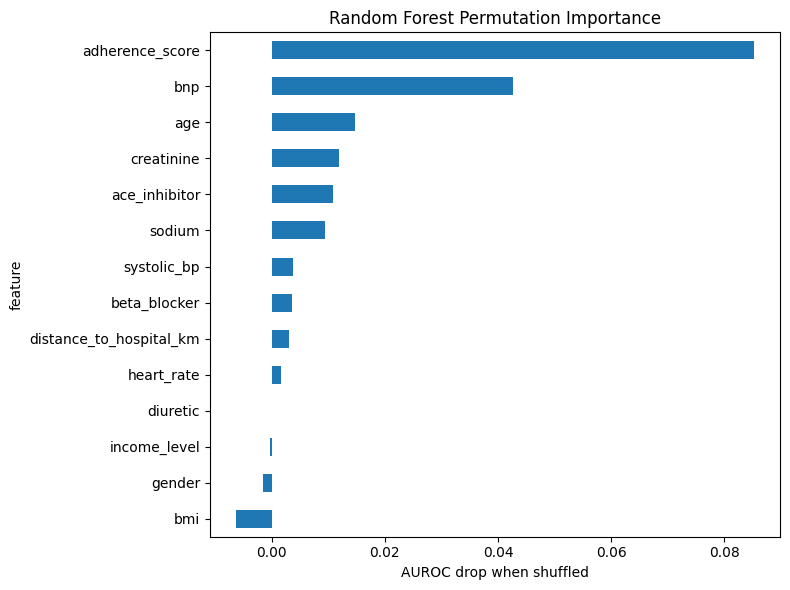

,feature,auroc_drop
11,adherence_score,0.0852
3,bnp,0.0426
0,age,0.0148
5,creatinine,0.0118
8,ace_inhibitor,0.0109
4,sodium,0.0095
6,systolic_bp,0.0038
9,beta_blocker,0.0035
13,distance_to_hospital_km,0.0031
7,heart_rate,0.0016


In [12]:
perm = permutation_importance(
    best_rf, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=42, n_jobs=-1
)

importance = pd.DataFrame({
    "feature": X.columns,
    "auroc_drop": perm.importances_mean,
}).sort_values("auroc_drop", ascending=False)
importance.to_csv(TABLES_DIR / "tbl_rf_permutation_importance.csv", index=False)

importance.sort_values("auroc_drop").plot.barh(x="feature", y="auroc_drop", legend=False, figsize=(8, 6))
plt.xlabel("AUROC drop when shuffled")
plt.title("Random Forest Permutation Importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_rf_permutation_importance.png", dpi=300)
plt.show()
importance.round(4)

## Comparison with logistic regression

Quick side-by-side with notebook 04's saved results (run 04 first). The full three-model table is
built in notebook 06.

In [13]:
logreg_path = TABLES_DIR / "tbl_model_results.csv"
if logreg_path.exists():
    logreg = pd.read_csv(logreg_path)
    combined = pd.concat([logreg, results], ignore_index=True)
    combined = combined.drop_duplicates(subset="model").sort_values("roc_auc", ascending=False)
    print(combined.round(4).to_string(index=False))
else:
    print("Run 04_modeling.ipynb first to compare against logistic regression.")

              model  accuracy  precision  recall     f1  roc_auc  average_precision  specificity
Logistic regression    0.6283     0.5706  0.3927 0.4652   0.6898             0.5636          NaN
      Random Forest    0.6283     0.5732  0.3806 0.4574   0.6812             0.5717       0.8017
     Dummy baseline    0.5883     0.0000  0.0000 0.0000   0.5000             0.4117          NaN


## Takeaways

- Random Forest reached test AUROC 0.68 and accuracy 0.63, clearly above the most-frequent baseline (0.59 accuracy, 0.50 AUROC), so it picked up a real but modest signal.
- Its metrics sit in the same band as logistic regression (AUROC 0.69) and HGBC (AUROC 0.67). The flexible tree model does not pull ahead, which matches the EDA: the features are weak and nearly uncorrelated, so there is little interaction structure for the trees to exploit.
- Permutation importance puts adherence_score well in front, followed by bnp and age, the same signals the EDA flagged. We use permutation importance here rather than the built-in feature_importances_, which is biased toward continuous features.
- Threshold tradeoff: at the default 0.50 cutoff recall is low (0.38) with high specificity (0.80). Lowering it to 0.30 (best validation F1) flips that to recall 0.85 / specificity 0.37, which is worth it for screening if missing an at-risk patient costs more than a false alarm.
- Since all three models cluster together, logistic regression is a reasonable final pick for its interpretability; Random Forest mainly confirms the performance ceiling is in the data.
- All results are associations on observational data, not causal effects.